## **Setup**

In [1]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

if IS_COLAB:
    !pip install optuna

Repo already exists — pulling latest changes
Already up to date.


In [2]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

## **Imports**

In [3]:
import numpy as np
import pandas as pd

from Challenge.paths import XGBOOST_DATAFRAMES

Running on local — storage at: /home/luigi/RecSys


## **Load Dataframes**

In [4]:
# Not sure if I shoul use prediction features to do correlation analysis
# Should be fine, I am only looking at feature correlation. No data leakage here.
file_path = os.path.join(XGBOOST_DATAFRAMES, "prediction_data.parquet")

df = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
df

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/prediction_data.parquet


,UserID,ItemID,TopPop_Score,TopPop_RankPosition,TopPop_Recommended,ItemKNN_cosine_Score,ItemKNN_cosine_RankPosition,ItemKNN_cosine_Recommended,ItemKNN_jaccard_Score,ItemKNN_jaccard_RankPosition,...,Mean_RankPosition,Std_RankPosition,Skew_RankPosition,Kurtosis_RankPosition,Mean_Score,Std_Score,Skew_Score,Kurtosis_Score,User_Profile_Len,Item_Global_Popularity
0,0,6054,0.149410,318,0,0.238791,446,0,0.275156,65,...,792.619019,1259.735596,3.424178,13.648808,0.155094,0.222226,2.062433,8.472574,96,1987
1,0,5705,0.228137,151,0,0.297280,285,0,0.192252,135,...,517.857117,1002.365845,3.909873,16.645828,0.221487,0.212462,1.968379,7.094590,96,3034
2,0,6022,0.044515,1248,0,0.317602,244,0,0.188949,144,...,731.095215,1318.600464,3.875400,16.406370,0.172204,0.239770,1.265970,5.161270,96,592
3,0,4349,0.014061,2542,0,0.186696,629,0,0.097078,326,...,940.571411,1462.672119,2.236995,4.635228,0.155703,0.187391,2.532954,8.595733,96,187
4,0,5723,0.279645,99,0,0.437175,102,0,0.575141,12,...,406.047607,989.302856,3.682582,14.145194,0.284984,0.233453,1.027589,1.420211,96,3719
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3807584,27094,2779,0.373186,44,0,0.000000,5919,0,0.000000,5843,...,2485.571533,2221.112793,0.821142,-0.875797,0.086936,0.229149,3.043848,11.408940,314,4963
3807585,27094,1339,0.528310,13,1,0.426378,96,0,0.382425,35,...,868.761902,1373.918823,1.627563,0.853245,0.272436,0.238561,1.084918,1.989917,314,7026
3807586,27094,5599,0.006166,3470,0,0.244005,376,0,0.114904,291,...,768.952393,1087.479858,2.089986,3.035373,0.192299,0.197321,2.571045,7.672733,314,82
3807587,27094,3767,0.166704,249,0,0.422187,101,0,0.251825,87,...,362.714294,986.927429,4.447657,20.083519,0.282693,0.215985,1.504674,4.420769,314,2217


## **Check correlation between columns**

In [5]:
# Calculate correlation matrix
correlation_matrix = df.corr()

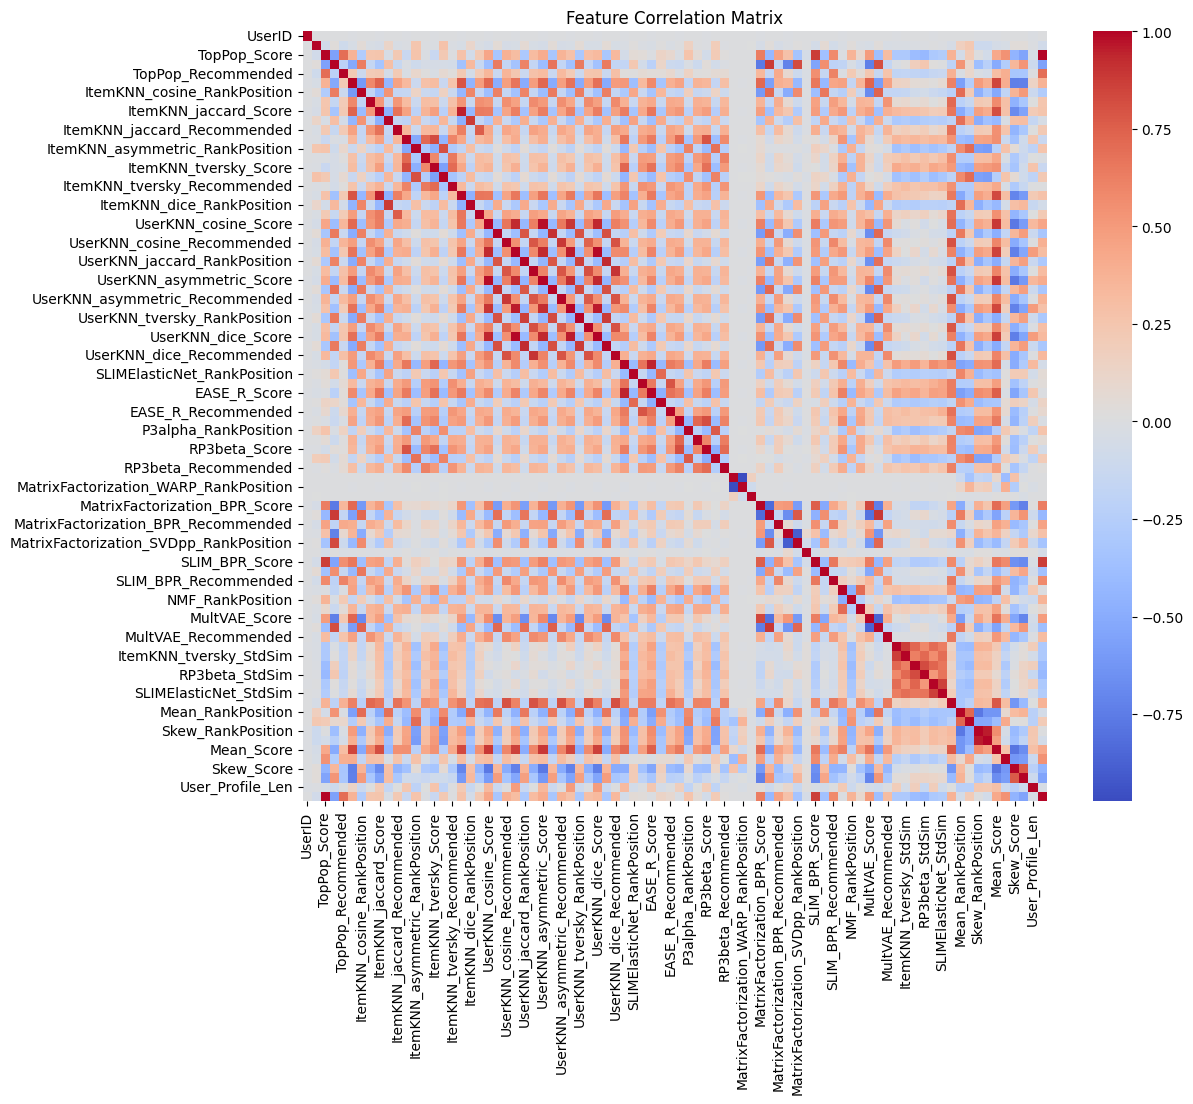

In [6]:
# Plot heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

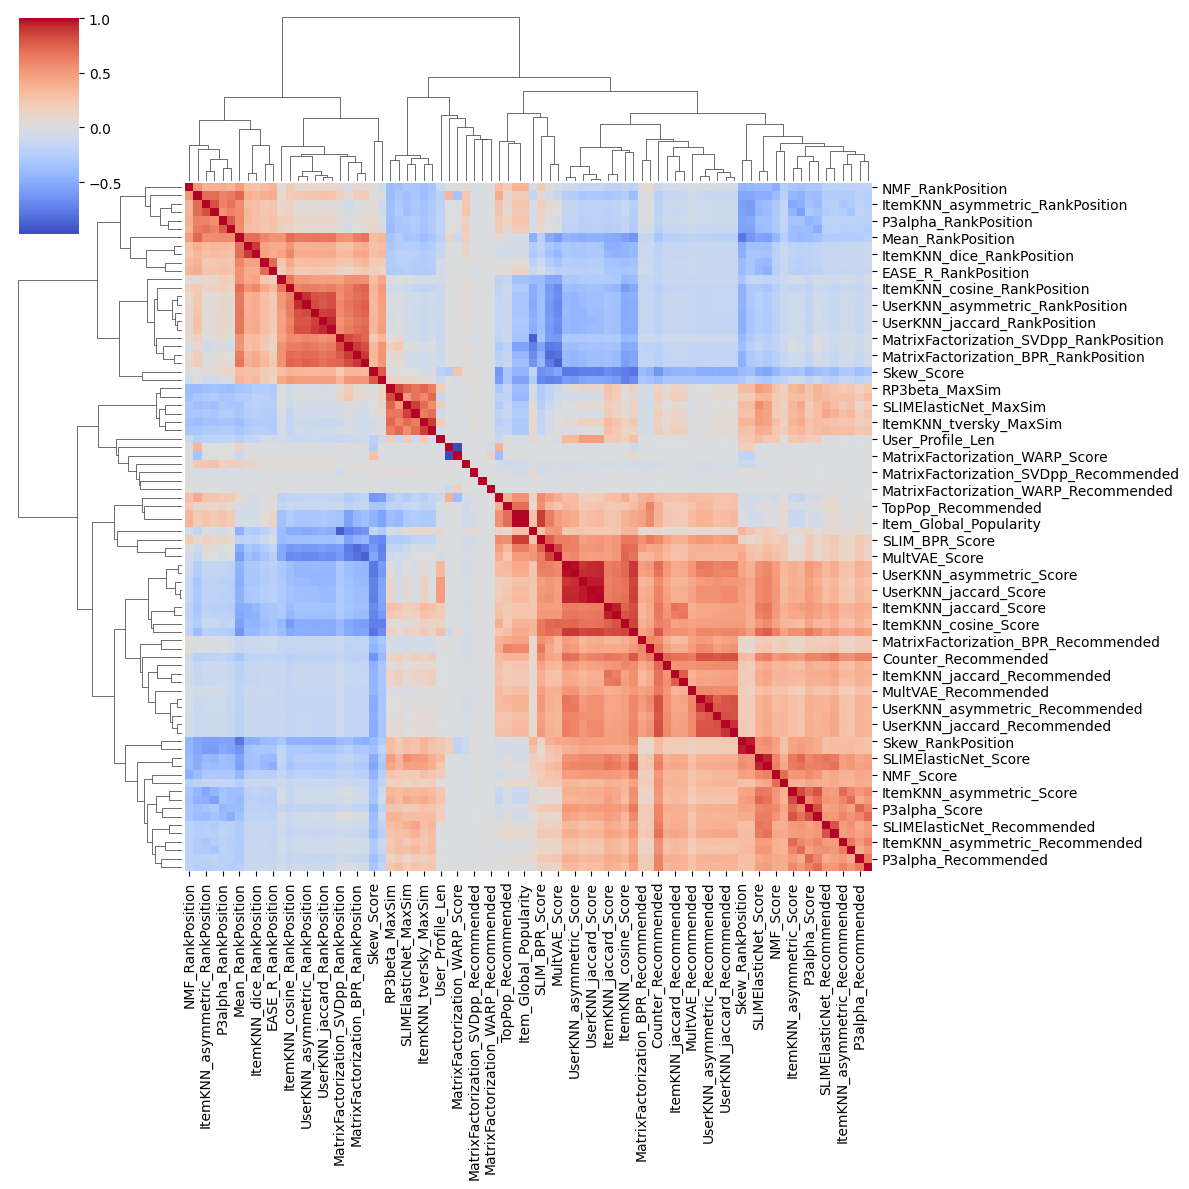

In [7]:
# No need to set figsize, clustermap handles it differently
sns.clustermap(correlation_matrix, annot=False, cmap='coolwarm', figsize=(12, 12))
plt.show()

In [ ]:
import numpy as np

def get_highly_correlated_features(df, threshold=0.95):
    # Create correlation matrix
    corr_matrix = df.corr().abs()
    
    # Select upper triangle of correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find features with correlation greater than threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    return to_drop

# Apply to your data
cols_to_drop = get_highly_correlated_features(df, threshold=0.9)
print(f"Dropping {len(cols_to_drop)} columns: {cols_to_drop}")

Dropping 12 columns: ['ItemKNN_dice_Score', 'UserKNN_jaccard_Score', 'UserKNN_asymmetric_Score', 'UserKNN_asymmetric_RankPosition', 'UserKNN_tversky_Score', 'UserKNN_dice_Score', 'UserKNN_dice_RankPosition', 'UserKNN_dice_Recommended', 'EASE_R_Score', 'MatrixFactorization_WARP_RankPosition', 'Kurtosis_RankPosition', 'Item_Global_Popularity']


In [10]:
df = df.drop(columns=cols_to_drop)

In [11]:
correlation_matrix = df.corr()

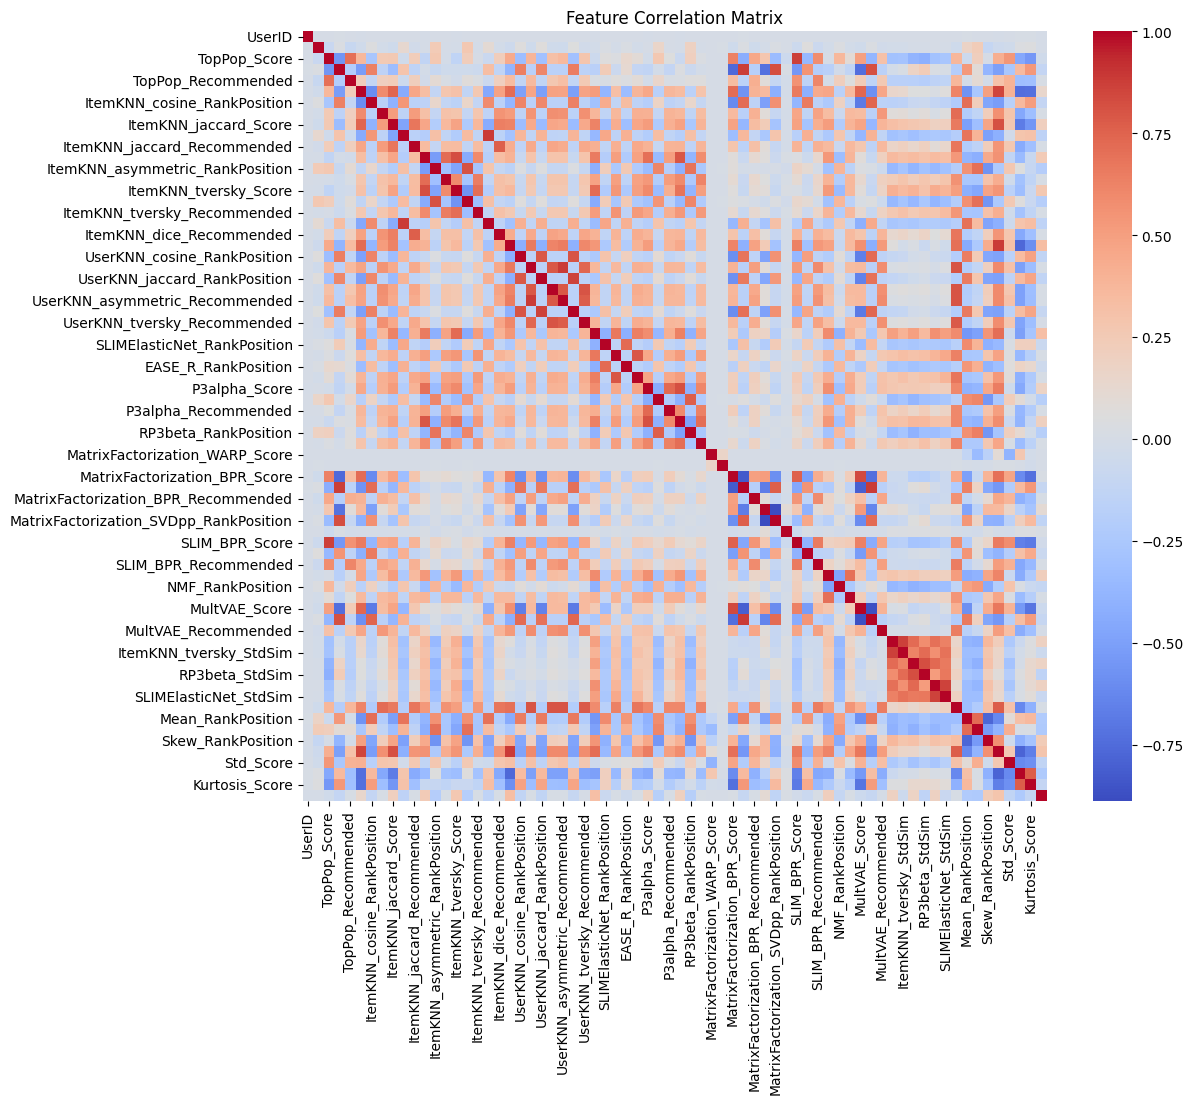

In [12]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

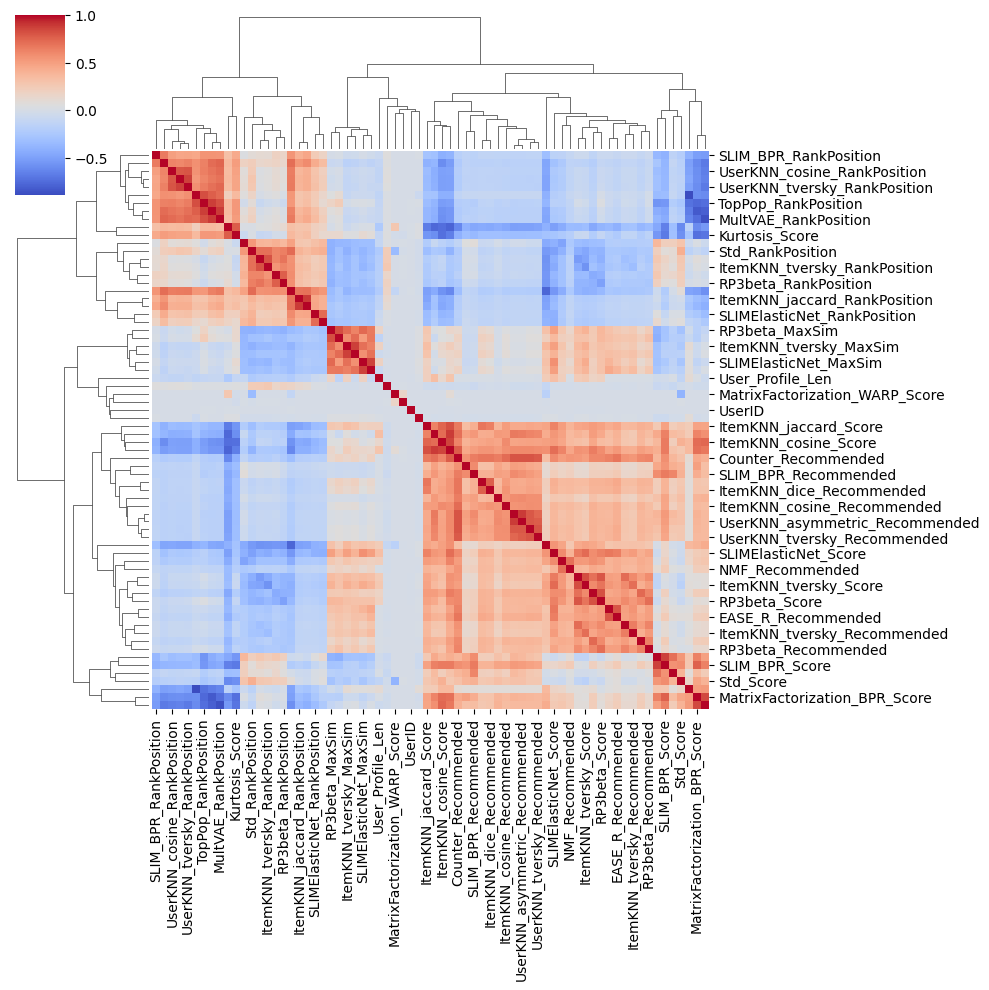

In [13]:
sns.clustermap(correlation_matrix, annot=False, cmap='coolwarm')
plt.show()

In [14]:
len(df.columns)

70

In [ ]:
save_path = os.path.join(XGBOOST_DATAFRAMES, "prediction_data.parquet")

df.to_parquet(
    path=save_path,
    engine='fastparquet',
    compression='zstd',
    index=False
)

print(f"Saved successfully to: {save_path}")

## **Drop too correlated columns from train and val dataframes**

In [ ]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "validation_data.parquet")

df = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
df

In [ ]:
val_cols_to_drop = get_highly_correlated_features(df, threshold=0.9)
print(f"Dropping {len(val_cols_to_drop)} columns: {val_cols_to_drop}")

assert val_cols_to_drop == cols_to_drop, "Mismatch in columns to drop between datasets"

In [ ]:
df = df.drop(columns=cols_to_drop)

In [ ]:
save_path = os.path.join(XGBOOST_DATAFRAMES, "validation_data.parquet")

df.to_parquet(
    path=save_path,
    engine='fastparquet',
    compression='zstd',
    index=False
)

print(f"Saved successfully to: {save_path}")

In [ ]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "training_data.parquet")

df = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
df

In [ ]:
val_cols_to_drop = get_highly_correlated_features(df, threshold=0.9)
print(f"Dropping {len(val_cols_to_drop)} columns: {val_cols_to_drop}")

assert val_cols_to_drop == cols_to_drop, "Mismatch in columns to drop between datasets"

In [ ]:
df = df.drop(columns=cols_to_drop)

In [ ]:
save_path = os.path.join(XGBOOST_DATAFRAMES, "validation_data.parquet")

df.to_parquet(
    path=save_path,
    engine='fastparquet',
    compression='zstd',
    index=False
)

print(f"Saved successfully to: {save_path}")